In [10]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing

In [11]:
data = fetch_california_housing(as_frame=True)
df = data.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [13]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("TRAIN R2:", r2_score(y_train, y_pred_train))
print("TEST R2:", r2_score(y_test, y_pred_test))

TRAIN R2: 0.6125511913966952
TEST R2: 0.5757877060324508


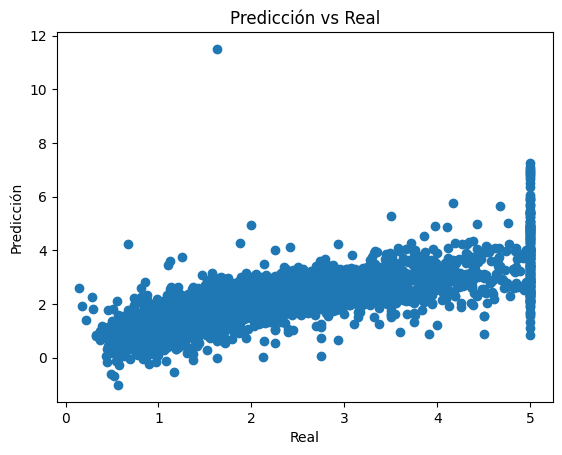

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_test)
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.show()

In [18]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_test_poly = model_poly.predict(X_test_poly)

print("POLY TEST R2:", r2_score(y_test, y_pred_test_poly))

POLY TEST R2: 0.6456819711504156


¿Qué modelo es mejor? ¿Cómo lo determinaron?

El modelo polinómico es mejor que el modelo lineal. Esto lo determiné comparando el valor de R² en el conjunto de test. El modelo lineal tiene un R² de aproximadamente 0.57, mientras que el modelo polinómico tiene un R² de aproximadamente 0.64. Como el modelo polinómico tiene un R² más alto, significa que logra predecir mejor los precios de las casas en datos que no fueron usados para entrenar.

¿Qué feature tiene más impacto en el precio? ¿Cómo lo averiguaron?

La variable que más impacta en el precio es MedInc (ingreso medio).
Esto lo averigüé observando los coeficientes del modelo de regresión lineal. Los coeficientes indican cuánto influye cada variable en la predicción.
La variable con el coeficiente más alto es la que más afecta al resultado. En este caso, el ingreso de las personas tiene una gran influencia en el precio de las viviendas, lo cual también tiene sentido en la vida real.

¿Hay señales de overfitting en alguno? ¿Cómo se dan cuenta?

No se observan señales claras de overfitting.
En el modelo lineal, los valores de R² en train (0.61) y test (0.57) son bastante parecidos.
En el modelo polinómico, el R² en train (0.68) es un poco mayor que en test (0.64), pero la diferencia no es muy grande.
Esto indica que el modelo polinómico es más complejo y se ajusta mejor, pero sin perder capacidad para generalizar a nuevos datos.